In [16]:
# 1. 下载开源中文字体 (SimHei 黑体) 到 Colab 环境
!wget -q -O SimHei.ttf "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 2. 将下载的字体动态注册到 matplotlib
fm.fontManager.addfont('SimHei.ttf')

# 3. 强制覆盖全局字体设置，并解决负号显示问题
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。")

✅ 中文字体环境配置完成！请现在去重新运行您的画图代码。


In [17]:
import pandas as pd
import plotly.express as px

# 1. 读取数据 (确保左侧文件栏有你的CSV)
file_path = '热力图数据.csv'
df = pd.read_csv(file_path)

# 2. 提取相对 X 和 Y 坐标
df[['X', 'Y']] = df['Coords'].str.split(',', expand=True).astype(float)

# 3. 经纬度换算
origin_lon = 113.5398  # 议事亭前地经度 (注：如果想用新葡京，请改为 113.5444)
origin_lat = 22.1936   # 议事亭前地纬度 (注：如果想用新葡京，请改为 22.1899)

# 换算比例：澳门纬度附近 1米 ≈ 0.0000090 度纬度，1米 ≈ 0.0000097 度经度
df['Lon'] = origin_lon + df['X'] * 0.0000097
df['Lat'] = origin_lat + df['Y'] * 0.0000090

# 4. 使用 Plotly 调用真实的在线地图绘制
fig = px.scatter_mapbox(
    df,
    lat="Lat",
    lon="Lon",
    hover_name="POI_Name",
    color="Match_Score",  # 数据依然读取 Match_Score 列
    color_continuous_scale=px.colors.sequential.YlOrRd,
    zoom=14,
    mapbox_style="carto-positron",  # 稳定且干净的浅色底图
    title="澳门 POI 真实地图热力分布 (以新葡京酒店为原点)",
    labels={"Match_Score": "综合推荐得分"}  # <--- 核心修改：通过 labels 字典将图表上的文字替换为中文
)

# 统一设置所有点的大小为 12
fig.update_traces(marker=dict(size=12))

# 5. 微调图表边距使其更美观
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

# 显示图表
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '热力图数据.csv'

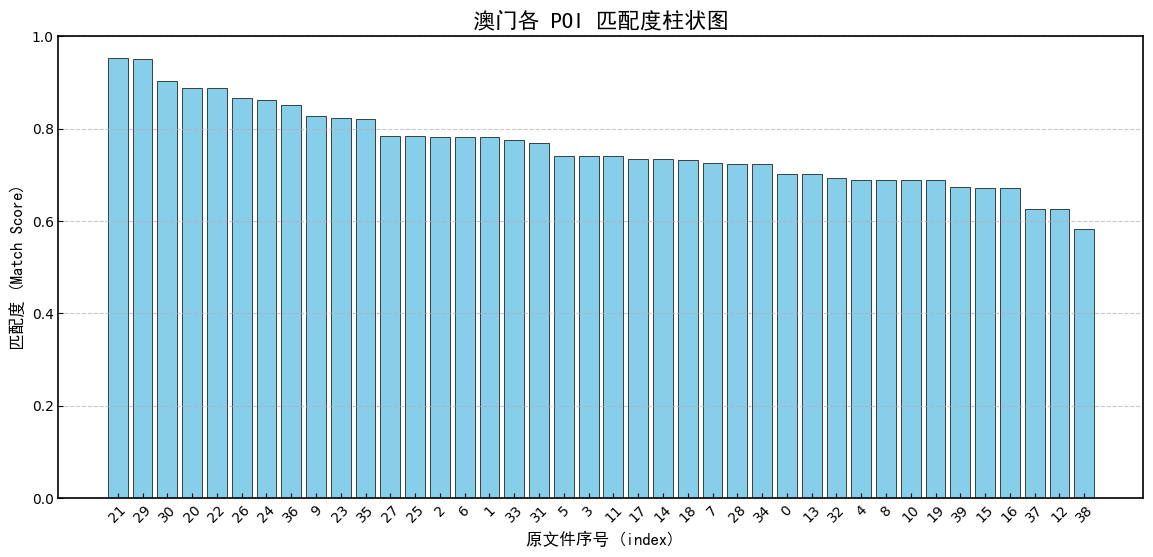

In [ ]:
# 1. 下载中文字体解决 Colab 乱码
!wget -q -O /tmp/SimHei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 2. 注册字体对象
font_title = FontProperties(fname='/tmp/SimHei.ttf', size=16)
font_label = FontProperties(fname='/tmp/SimHei.ttf', size=12)
plt.rcParams['axes.unicode_minus'] = False

# 3. 读取数据
file_path = '热力图数据.csv'
df = pd.read_csv(file_path)

# 4. 绘图配置
plt.figure(figsize=(14, 6)) # 稍微把图拉宽一点，因为序号比较多

# 5. 绘制柱状图
# 注意：为了让 X 轴的刻度对齐序号，我们将 index 转换为字符串类型
bars = plt.bar(
    df['index'].astype(str),
    df['Match_Score'],
    color='skyblue',
    edgecolor='black',
    linewidth=0.5
)

# 6. 添加中文装饰
plt.title('澳门各 POI 匹配度柱状图', fontproperties=font_title)
plt.xlabel('原文件序号 (index)', fontproperties=font_label)
plt.ylabel('匹配度 (Match Score)', fontproperties=font_label)

# 为了防止序号太多挤在一起，可以将 X 轴标签稍微旋转一下
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) # 仅保留横向网格线

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import math
# 如果在 Colab 中运行，这行可以用来触发文件下载
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def cosine_similarity(v1, v2):
    """计算余弦相似度"""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return 0.0 if norm_v1 == 0 or norm_v2 == 0 else dot_product / (norm_v1 * norm_v2)

def calculate_best_merchant(user_pref, merchants, v_max=2000, enable_vj=True):
    """
    计算单个用户在特定地理围栏内的最优推荐商户
    :param enable_vj: bool, 是否启用扶助变量 V_j (实验组=True, 对照组=False)
    """
    best_merchant = None
    max_score = -1.0

    for m_id, m_data in merchants.items():
        P_j = m_data['features']
        R_j = m_data['rating']
        v_j = m_data['reviews']

        M_ij = cosine_similarity(user_pref, P_j)

        # 一票否决机制
        if R_j < 3.8:
            score = 0
        else:
            # 贝叶斯平滑
            w = v_j / (v_j + 30)
            Q_j = w * R_j + (1 - w) * 3.5

            # 扶助变量逻辑
            if enable_vj:
                E_j = math.log10(v_j + 1) / math.log10(v_max + 1)
                V_j = 1 - E_j
                score = M_ij * ((Q_j / 5.0) + 0.668 * V_j)
            else:
                # 拔除扶助变量
                score = M_ij * (Q_j / 5.0)

        # 记录最高分商户
        if score > max_score:
            max_score = score
            best_merchant = m_id

    return best_merchant

if __name__ == "__main__":
# 1. 准备商户数据 (特征向量: [网红打卡属性, 本土生活程度, 店龄传承底蕴])
    database_geo_fences = {
        # 原有商户
        "大三巴百年饼家": {"features": np.array([0.2, 0.9, 0.9]), "rating": 4.5, "reviews": 1200},
        "牌坊打卡冰室": {"features": np.array([0.9, 0.3, 0.2]), "rating": 4.6, "reviews": 1200},
        "巷仔阿伯猪扒包": {"features": np.array([0.3, 0.9, 0.8]), "rating": 4.8, "reviews": 300},
        "街角流水线葡挞": {"features": np.array([0.8, 0.1, 0.1]), "rating": 3.4, "reviews": 850},  # 触发否决
        "顶楼全景高级餐吧": {"features": np.array([0.9, 0.2, 0.1]), "rating": 4.2, "reviews": 340},

        # 新增商户
        "老街手打瓦煲咖啡": {"features": np.array([0.4, 0.8, 0.7]), "rating": 4.7, "reviews": 450},   # 本地口碑好，有一定历史
        "霓虹潮牌快闪茶饮": {"features": np.array([0.95, 0.1, 0.05]), "rating": 4.1, "reviews": 1200}, # 纯网红打卡，评价基数极大
        "隐世老字号牛杂": {"features": np.array([0.6, 0.9, 0.9]), "rating": 4.9, "reviews": 780},    # 实力强劲的六边形战士(偏传统)
        "文创街景特调咖啡": {"features": np.array([0.8, 0.5, 0.3]), "rating": 4.4, "reviews": 600},    # 偏网红与本地生活结合的文青店
        "某大型连锁快餐店": {"features": np.array([0.3, 0.2, 0.1]), "rating": 3.6, "reviews": 3500}   # 触发否决 (评分<3.8)，毫无特色但评论多
    }

    # 2. 生成游客母体 (1000名具备随机偏好的游客)
    np.random.seed(42) # 固定随机种子以保证结果可复现
    num_tourists = 10000
    # 生成 10000 行 3 列的随机矩阵，代表 10000 个游客的三维偏好向量 [0.0, 1.0)
    virtual_tourists = np.random.rand(num_tourists, 3)

    # 3. 记录实验结果
    control_group_results = []      # 对照组 (去除了 V_j)
    experimental_group_results = [] # 实验组 (包含了 V_j)

    print("开始进行 1,000 名游客的模拟引流...")

    for i in range(num_tourists):
        user_pref = virtual_tourists[i]

        # 对照组 (Ablation: Force 0.2 * V_j = 0)
        dest_control = calculate_best_merchant(user_pref, database_geo_fences, enable_vj=False)
        control_group_results.append(dest_control)

        # 实验组 (完整公式: 包含 + 0.2 * V_j)
        dest_experimental = calculate_best_merchant(user_pref, database_geo_fences, enable_vj=True)
        experimental_group_results.append(dest_experimental)

    # 4. 数据统计与对比
    df_results = pd.DataFrame({
        '游客ID': range(1, num_tourists + 1),
        '对照组去向(无扶助)': control_group_results,
        '实验组去向(含扶助)': experimental_group_results
    })

    # 统计各商户在两组中的获客数量
    control_counts = df_results['对照组去向(无扶助)'].value_counts().rename('对照组客流量(人)')
    experimental_counts = df_results['实验组去向(含扶助)'].value_counts().rename('实验组客流量(人)')

    # 合并为一个对比表格
    comparison_df = pd.concat([control_counts, experimental_counts], axis=1).fillna(0).astype(int)
    comparison_df['流量变化'] = comparison_df['实验组客流量(人)'] - comparison_df['对照组客流量(人)']

    print("\n=== [引流结果对比] ===")
    print(comparison_df.to_string())

    # 5. 导出结果为 CSV
    export_filename = "tourist_simulation_results.csv"
    comparison_df.to_csv(export_filename, encoding='utf-8-sig') # utf-8-sig 保证 Excel 打开中文不乱码
    print(f"\n✅ 结果已汇总并保存至 '{export_filename}'")

    # 如果在 Colab 环境下，自动触发文件下载
    if IN_COLAB:
        print("正在为您下载 CSV 文件...")
        files.download(export_filename)

开始进行 1,000 名游客的模拟引流...

=== [引流结果对比] ===
          对照组客流量(人)  实验组客流量(人)  流量变化
隐世老字号牛杂        6502       2945 -3557
牌坊打卡冰室         1912        163 -1749
巷仔阿伯猪扒包        1143       4346  3203
文创街景特调咖啡        411       1624  1213
大三巴百年饼家          22          0   -22
老街手打瓦煲咖啡         10        156   146
顶楼全景高级餐吧          0        766   766

✅ 结果已汇总并保存至 'tourist_simulation_results.csv'
正在为您下载 CSV 文件...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

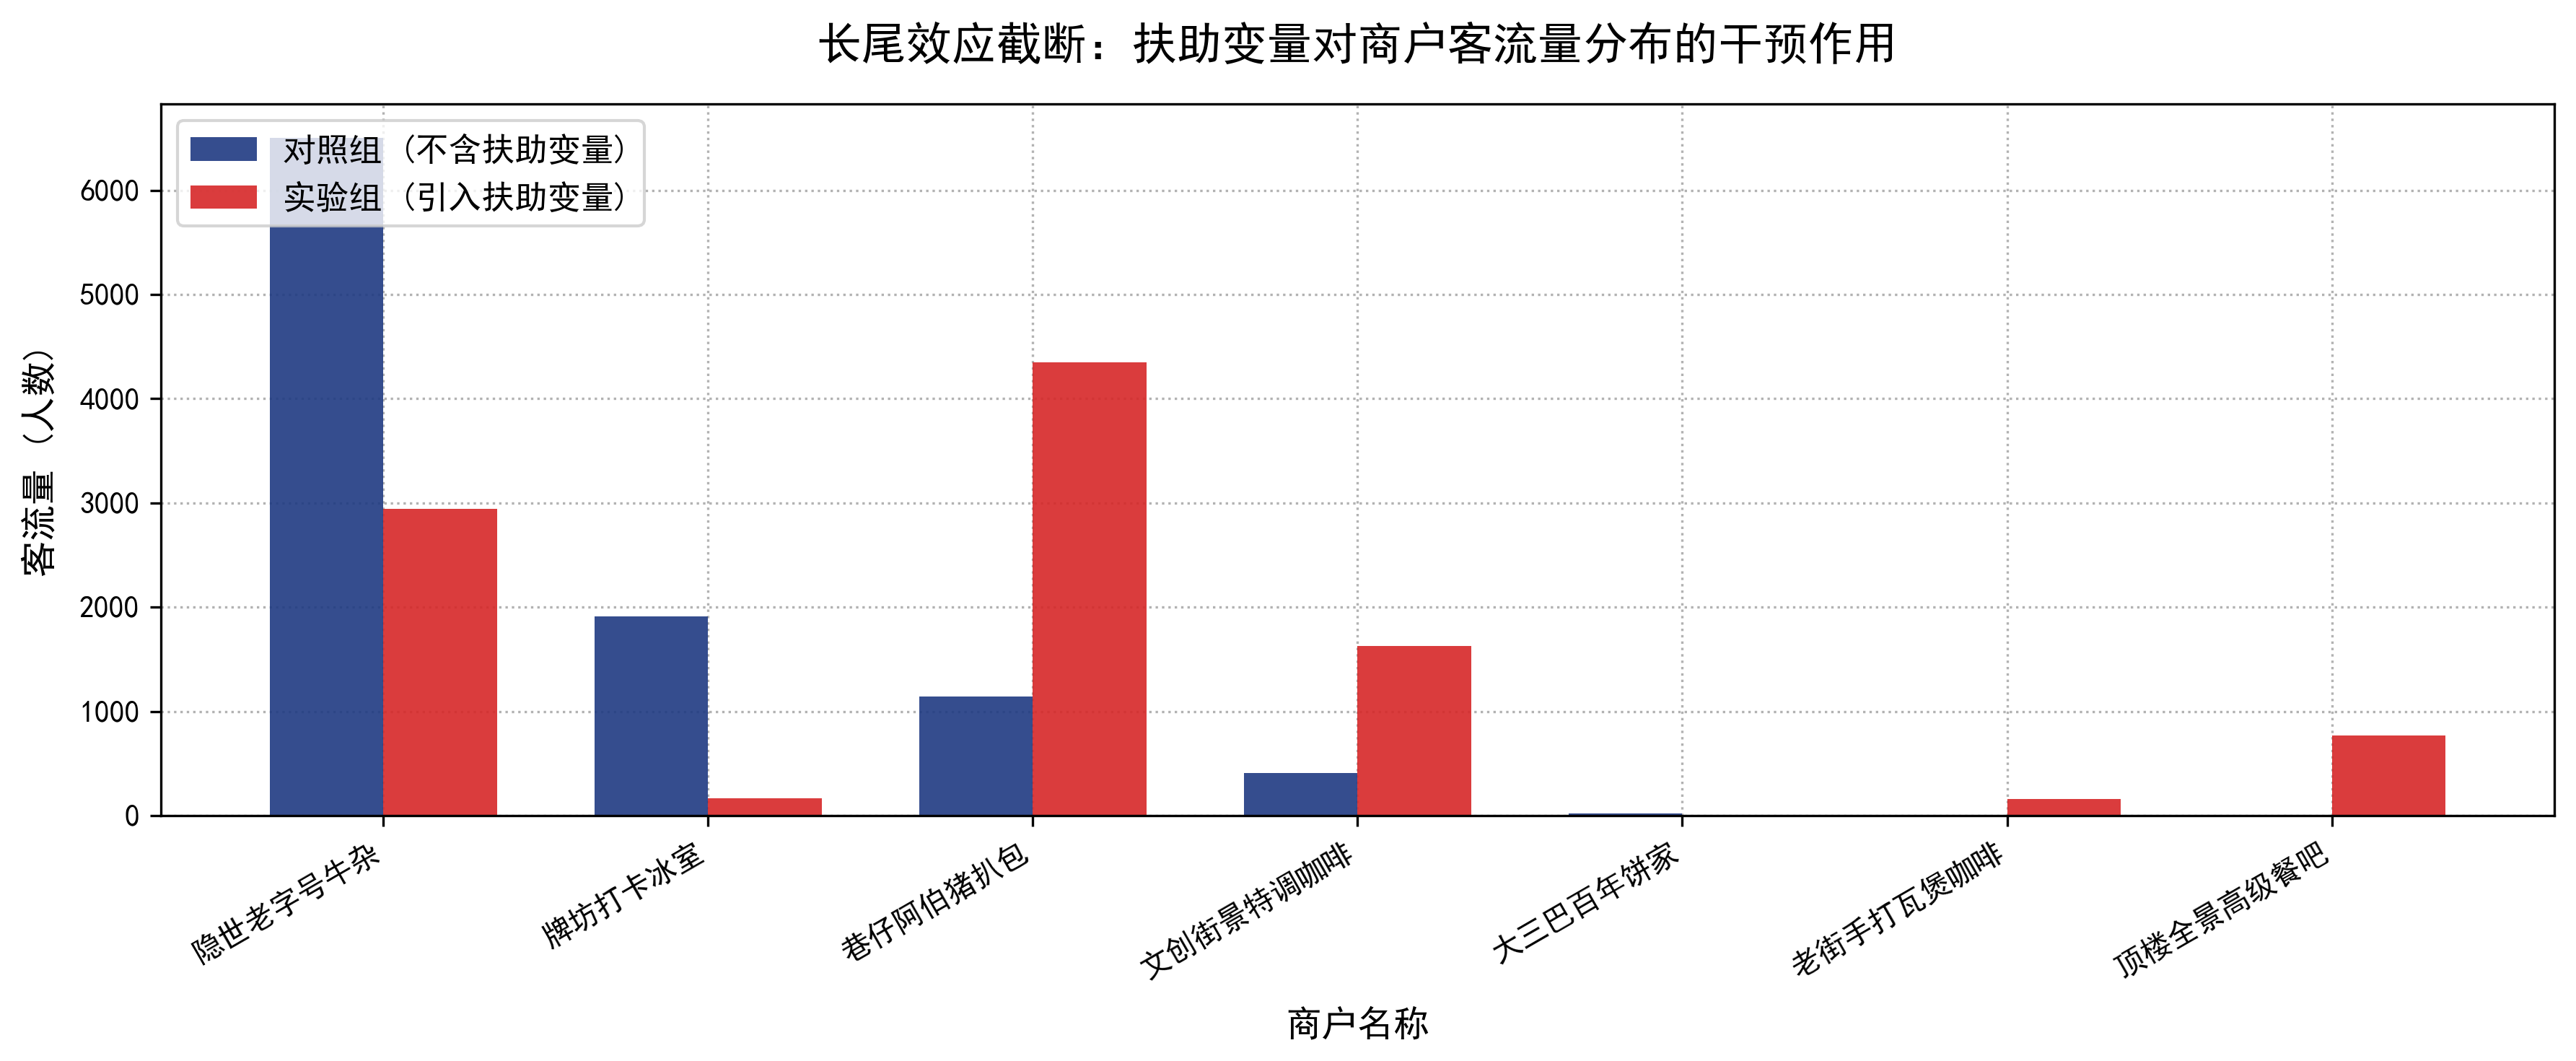

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import numpy as np
import os
import urllib.request

# ==========================================
# 1. 字体下载与强制实体化 (完全绕过缓存)
# ==========================================
font_path = "SimHei.ttf"
if not os.path.exists(font_path):
    print("⏳ 正在 Colab 中下载中文字体...")
    try:
        urllib.request.urlretrieve("https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf", font_path)
        print("✅ 字体下载完成！")
    except Exception as e:
        print(f"⚠️ 字体下载失败: {e}")

# 【核心改动】不再使用全局 rcParams，而是直接创建不同字号的字体实体对象
if os.path.exists(font_path):
    zh_font_title = fm.FontProperties(fname=font_path, size=15, weight='bold')
    zh_font_label = fm.FontProperties(fname=font_path, size=12)
    zh_font_tick  = fm.FontProperties(fname=font_path, size=10)
    zh_font_legend = fm.FontProperties(fname=font_path, size=11)
else:
    # 极端降级情况
    zh_font_title = zh_font_label = zh_font_tick = zh_font_legend = fm.FontProperties()

mpl.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# ==========================================
# 2. 读取并处理数据
# ==========================================
# 读取数据，假设第一列（商户名）作为索引
df = pd.read_csv('tourist_simulation_results.csv', index_col=0)

# 确保按照“对照组客流量”降序排列
plot_df = df.sort_values(by='对照组客流量(人)', ascending=False)

# 提取作图所需的数据维度
merchants = plot_df.index.tolist()
control_traffic = plot_df['对照组客流量(人)'].values
experimental_traffic = plot_df['实验组客流量(人)'].values

x = np.arange(len(merchants))  # X轴标签位置
width = 0.35                   # 柱子宽度

# ==========================================
# 3. 绘制图表
# ==========================================
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# 对照组
rects1 = ax.bar(x - width/2, control_traffic, width,
                label='对照组 (不含扶助变量)',
                color='#1F3A82', alpha=0.9)

# 实验组
rects2 = ax.bar(x + width/2, experimental_traffic, width,
                label='实验组 (引入扶助变量)',
                color='#D62728', alpha=0.9)

# ==========================================
# 4. 图表结构与格式规范化 (强制注入中文字体)
# ==========================================
# 标题与 XY 轴标签注入 fontproperties
ax.set_title('长尾效应截断：扶助变量对商户客流量分布的干预作用', fontproperties=zh_font_title, pad=15)
ax.set_ylabel('客流量 (人数)', fontproperties=zh_font_label, labelpad=8)
ax.set_xlabel('商户名称', fontproperties=zh_font_label, labelpad=8)

# X轴刻度注入 fontproperties
ax.set_xticks(x)
ax.set_xticklabels(merchants, fontproperties=zh_font_tick, rotation=30, ha="right")

# 图例注入 prop (注意：图例的参数名叫 prop，不是 fontproperties)
ax.legend(prop=zh_font_legend, loc='upper left', frameon=True, shadow=False)

# 网格与边框
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_visible(True)

# 紧凑布局避免边缘被截断
fig.tight_layout()

plt.show()

/tmp/ipykernel_59660/3908859334.py:96: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) SimHei.
  plt.tight_layout()
/tmp/ipykernel_59660/3908859334.py:96: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  plt.tight_layout()
/tmp/ipykernel_59660/3908859334.py:96: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) SimHei.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_

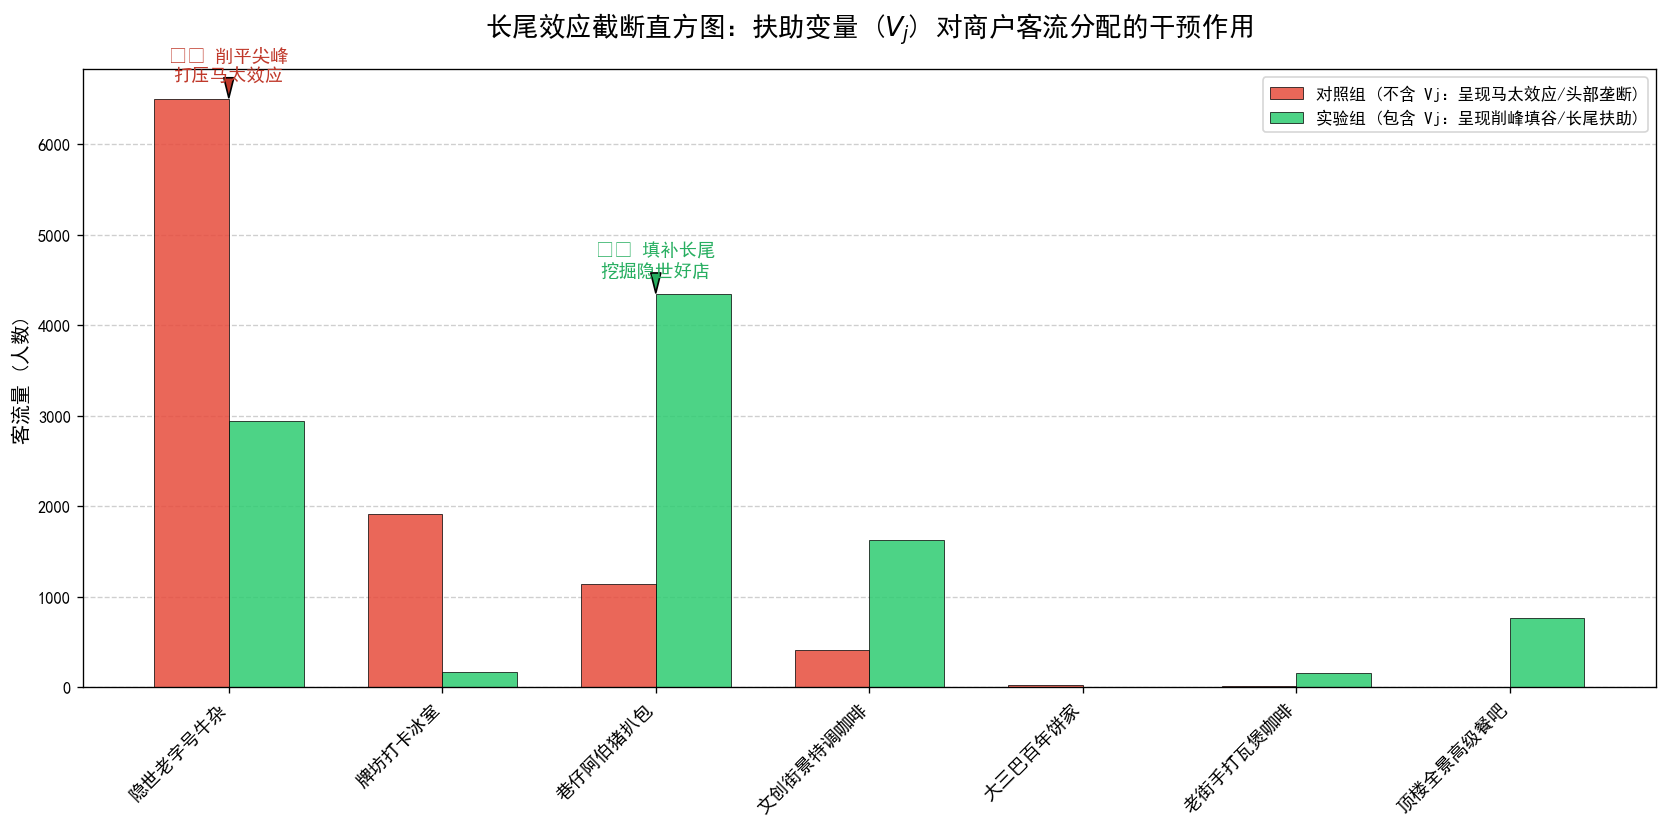

In [ ]:
# 引入可视化库
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os
import urllib.request

# ==========================================
# 1. 中文字体兼容处理 (专为 Colab 环境准备)
# ==========================================
font_path = "SimHei.ttf"
if IN_COLAB and not os.path.exists(font_path):
    print("⏳ 检测到 Colab 环境，正在下载中文字体...")
    try:
        # 下载黑体字体文件以解决乱码
        urllib.request.urlretrieve("https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf", font_path)
        print("✅ 字体下载完成！")
    except Exception as e:
        print(f"⚠️ 字体下载失败，图表可能出现方块乱码。错误信息: {e}")

# 设置字体属性
if os.path.exists(font_path):
    my_font = fm.FontProperties(fname=font_path)
else:
    # 兼容本地环境运行
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    my_font = fm.FontProperties()

# ==========================================
# 2. 数据准备：按对照组(无扶助)流量降序，呈现长尾分布
# ==========================================
# 复用单元格1的数据，进行降序排列
plot_df = comparison_df.sort_values(by='对照组客流量(人)', ascending=False)

merchants = plot_df.index.tolist()
control_traffic = plot_df['对照组客流量(人)'].values
experimental_traffic = plot_df['实验组客流量(人)'].values

x = np.arange(len(merchants))  # X轴标签位置
width = 0.35                   # 柱子宽度

# ==========================================
# 3. 绘制双柱状图对比
# ==========================================
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# 绘制柱状图 (调整颜色区分度，采用对比色)
rects1 = ax.bar(x - width/2, control_traffic, width,
                label='对照组 (不含 Vj：呈现马太效应/头部垄断)',
                color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=0.5)

rects2 = ax.bar(x + width/2, experimental_traffic, width,
                label='实验组 (包含 Vj：呈现削峰填谷/长尾扶助)',
                color='#2ECC71', alpha=0.85, edgecolor='black', linewidth=0.5)

# ==========================================
# 4. 图表细节装饰与文字排版
# ==========================================
ax.set_ylabel('客流量 (人数)', fontproperties=my_font, fontsize=12)
ax.set_title('长尾效应截断直方图：扶助变量 ($V_j$) 对商户客流分配的干预作用',
             fontproperties=my_font, fontsize=16, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(merchants, fontproperties=my_font, rotation=45, ha="right", fontsize=11)
ax.legend(prop=my_font, fontsize=11, loc='upper right')

# 添加虚线网格线以增强数据对齐感
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True) # 让网格线处于柱子后方

# ==========================================
# 5. 添加核心视觉高亮 (削峰 / 填谷 箭头指示)
# ==========================================
# 找出流量减少最多的头部商户（削平尖峰）
peak_idx = np.argmin(plot_df['流量变化'].values)
# 找出流量增加最多的尾部商户（填补长尾）
tail_idx = np.argmax(plot_df['流量变化'].values)

# 注释：削峰
if plot_df['流量变化'].iloc[peak_idx] < 0:
    ax.annotate('⬇️ 削平尖峰\n打压马太效应',
                xy=(peak_idx, control_traffic[peak_idx]),
                xytext=(peak_idx, control_traffic[peak_idx] + 200),
                fontproperties=my_font, color='#C0392B', ha='center', fontsize=11,
                arrowprops=dict(facecolor='#C0392B', shrink=0.05, width=1.5, headwidth=6))

# 注释：填谷
if plot_df['流量变化'].iloc[tail_idx] > 0:
    ax.annotate('⬆️ 填补长尾\n挖掘隐世好店',
                xy=(tail_idx, experimental_traffic[tail_idx]),
                xytext=(tail_idx, experimental_traffic[tail_idx] + 200),
                fontproperties=my_font, color='#27AE60', ha='center', fontsize=11,
                arrowprops=dict(facecolor='#27AE60', shrink=0.05, width=1.5, headwidth=6))

plt.tight_layout()
plt.show()

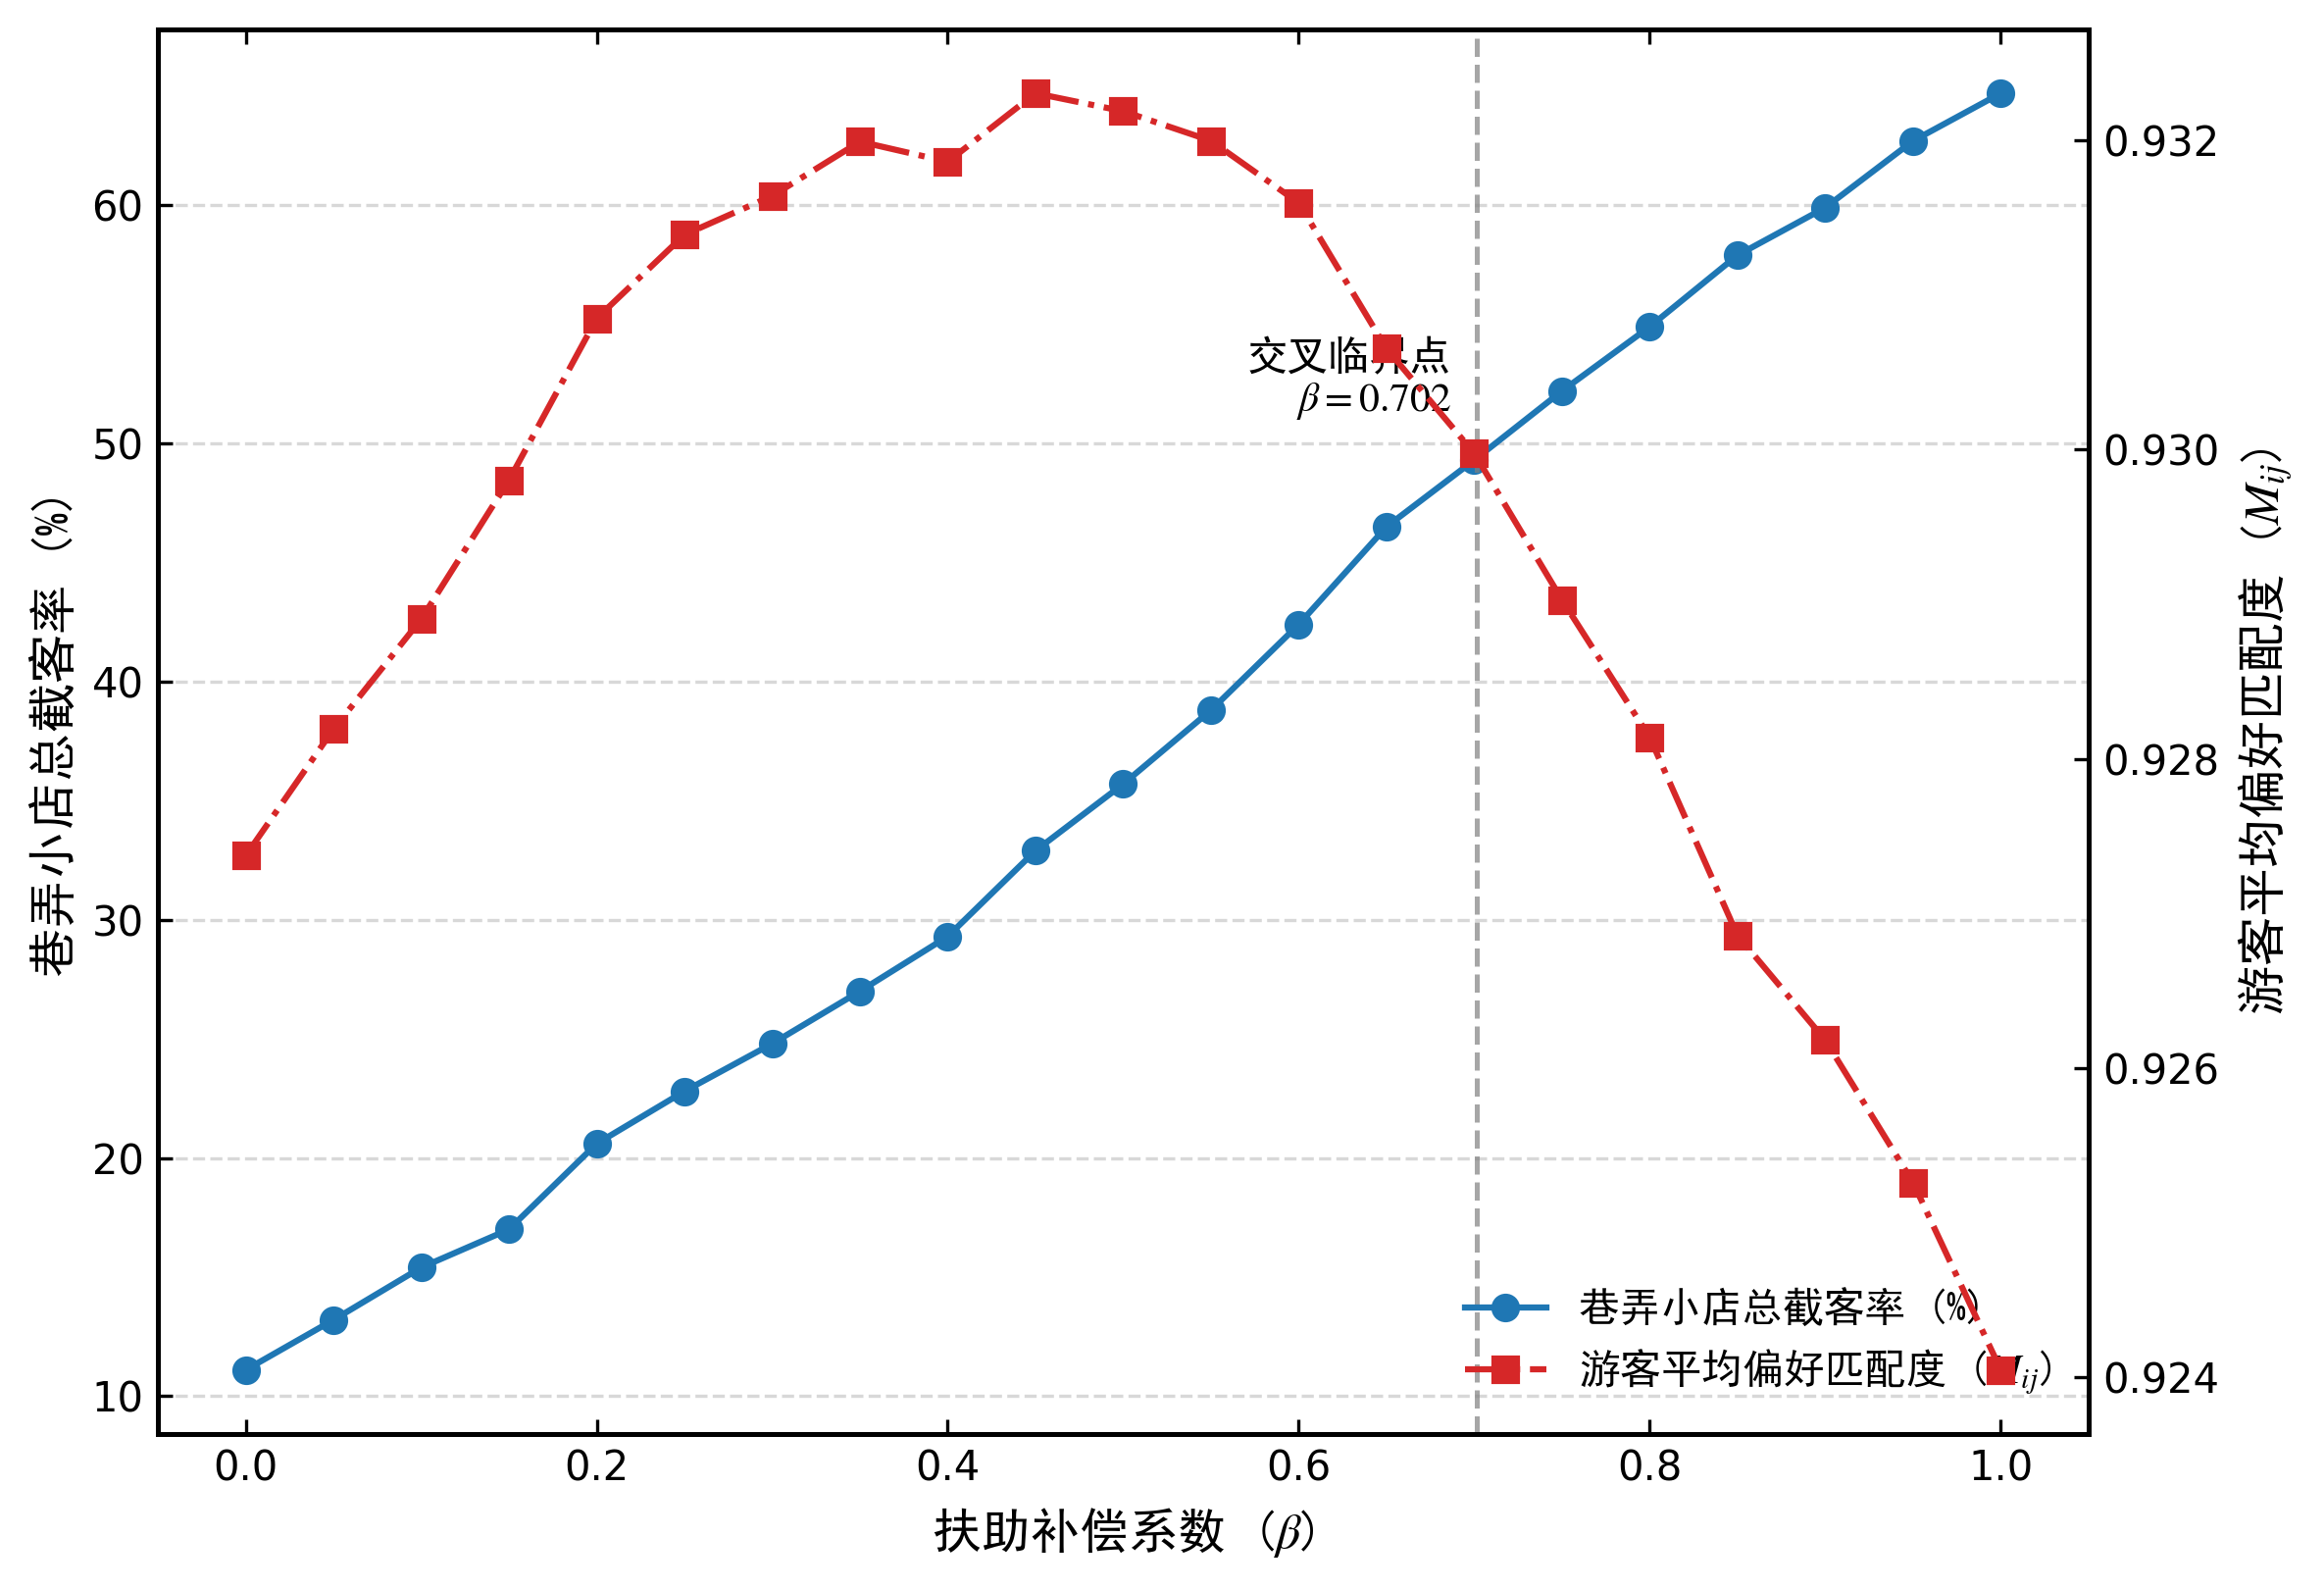

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ==========================================
# === 0. 全局排版与学术字体设置 (IEEE/Nature风格)
# ==========================================
# 设置全局英文和数字字体为 Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# 将数学公式（如 $\beta$, $M_{ij}$）字体设置为接近 Times New Roman 的 stix
plt.rcParams['mathtext.fontset'] = 'stix'

# 坐标轴线宽和刻度方向 (学术标准：四周封闭、刻度朝内)
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 解决 Colab 中的中文字体问题
# 注：Colab 默认无 SimSun（宋体），这里使用开源的 SimHei 作为回退保证代码可运行。
# 若在本地环境运行，建议直接将路径替换为本地的 SimSun.ttf 即可获得完美的宋体效果。
font_filename = 'SimHei.ttf'
if not os.path.exists(font_filename):
    os.system(f'wget -q -O {font_filename} https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf')
try:
    zh_font = fm.FontProperties(fname=font_filename, size=12)
    zh_font_legend = fm.FontProperties(fname=font_filename, size=10)
    zh_font_anno = fm.FontProperties(fname=font_filename, size=10)
except Exception:
    zh_font = fm.FontProperties(family='sans-serif', size=12)
    zh_font_legend = fm.FontProperties(family='sans-serif', size=10)
    zh_font_anno = fm.FontProperties(family='sans-serif', size=10)


# ==========================================
# === 1. 核心数据与算法 (保持原逻辑)
# ==========================================
SMALL_SHOP_THRESHOLD = 500

def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    return 0.0 if dot == 0 else dot / (np.linalg.norm(v1) * np.linalg.norm(v2))

def calculate_best_merchant(user_pref, merchants, beta, v_max=3500):
    best_merchant, chosen_M_ij = None, 0.0
    max_score = -1.0
    for m_id, m_data in merchants.items():
        if m_data['rating'] < 3.8: continue
        M_ij = cosine_similarity(user_pref, m_data['features'])
        w = m_data['reviews'] / (m_data['reviews'] + 30)
        Q_j = w * m_data['rating'] + (1 - w) * 3.5
        V_j = 1 - (math.log10(m_data['reviews'] + 1) / math.log10(v_max + 1))
        score = M_ij * ((Q_j / 5.0) + beta * V_j)
        if score > max_score:
            max_score, best_merchant, chosen_M_ij = score, m_id, M_ij
    return best_merchant, chosen_M_ij

# ==========================================
# === 2. 模拟运行 (保持原逻辑)
# ==========================================
np.random.seed(42)
num_tourists = 1000
virtual_tourists = np.random.rand(num_tourists, 3)
betas = np.arange(0.0, 1.05, 0.05)
exposure_rates, avg_matches = [], []

for beta in betas:
    small_shop_hits, total_M_ij, valid_recommends = 0, 0.0, 0
    for i in range(num_tourists):
        dest, m_ij = calculate_best_merchant(virtual_tourists[i], database_geo_fences, beta=beta)
        if dest:
            valid_recommends += 1
            total_M_ij += m_ij
            if database_geo_fences[dest]['reviews'] <= SMALL_SHOP_THRESHOLD:
                small_shop_hits += 1

    exposure_rates.append((small_shop_hits / valid_recommends * 100) if valid_recommends > 0 else 0)
    avg_matches.append((total_M_ij / valid_recommends) if valid_recommends > 0 else 0)


# ==========================================
# === 3. 学术级双 Y 轴重绘
# ==========================================
fig, ax1 = plt.subplots(figsize=(8, 5.5), dpi=300) # 高分辨率输出

color1 = '#1f77b4' # 学术蓝
color2 = '#d62728' # 学术红/砖红

# --- 左 Y 轴：巷弄小店总截客率 ---
ax1.set_xlabel('扶助补偿系数 ($\\beta$)', fontproperties=zh_font)
ax1.set_ylabel('巷弄小店总截客率 (%)', fontproperties=zh_font)
line1 = ax1.plot(betas, exposure_rates, color=color1, linestyle='-', marker='o',
                 linewidth=1.5, markersize=6, label='巷弄小店总截客率 (%)')

# 仅保留水平浅灰色虚线网格，避免图面杂乱
ax1.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

# --- 右 Y 轴：游客平均偏好匹配度 ---
ax2 = ax1.twinx()
ax2.set_ylabel('游客平均偏好匹配度 ($M_{ij}$)', fontproperties=zh_font)
line2 = ax2.plot(betas, avg_matches, color=color2, linestyle='-.', marker='s',
                 linewidth=1.5, markersize=6, label='游客平均偏好匹配度 ($M_{ij}$)')

# 强制显示上下左右全包围的边框 (Boxed Style)
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)

# 确保所有坐标轴的刻度都朝内显示
ax1.tick_params(axis='x', top=True, bottom=True)
ax1.tick_params(axis='y', left=True, right=False) # 右侧 Y 轴刻度由 ax2 接管
ax2.tick_params(axis='y', right=True, direction='in')

# 强制画布更新以捕捉真实的 Y 轴范围，为后续几何求解铺垫
fig.canvas.draw()
ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

# ==========================================
# === 4. 几何求解视觉交叉点
# ==========================================
v_exp = (np.array(exposure_rates) - ymin1) / (ymax1 - ymin1)
v_mat = (np.array(avg_matches) - ymin2) / (ymax2 - ymin2)

cross_betas = []
cross_y_vis_list = []

for i in range(len(betas) - 1):

    if (v_exp[i] - v_mat[i]) * (v_exp[i+1] - v_mat[i+1]) <= 0:
        x1, x2 = betas[i], betas[i+1]
        y1a, y2a = v_exp[i], v_exp[i+1]
        y1b, y2b = v_mat[i], v_mat[i+1]

        slope_a = (y2a - y1a) / (x2 - x1)
        slope_b = (y2b - y1b) / (x2 - x1)

        if slope_a != slope_b:
            cross_beta = x1 + (y1b - y1a) / (slope_a - slope_b)
            if cross_beta > 0.05:
                cross_y_vis = y1a + slope_a * (cross_beta - x1)
                cross_betas.append(cross_beta)
                cross_y_vis_list.append(cross_y_vis)

# ==========================================
# === 5. 学术风格辅助线与标注
# ==========================================
if cross_betas:
    final_cross_beta = cross_betas[-1]
    final_cross_y_vis = cross_y_vis_list[-1]
    cross_exp_real = ymin1 + final_cross_y_vis * (ymax1 - ymin1)

    # 绘制低调的深灰色半透明虚线
    ax1.axvline(x=final_cross_beta, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

    # 极简纯文本标注，使用白色底色防遮挡网格和折线 (无边框)
    # 将显示图层提到最高 (添加 zorder=10)，约等于改为等于 (\\approx 改为 =)
    bbox_props = dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2)
    ax1.text(final_cross_beta - 0.015, cross_exp_real + 1.5,
             f'交叉临界点\n$\\beta = {final_cross_beta:.3f}$',
             fontproperties=zh_font_anno, color='black',
             ha='right', va='bottom', bbox=bbox_props, zorder=10000)

# --- 图例合并与样式 ---
# 将两条线索合并，放在右下角，并去除外边框 (符合顶刊审美)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', frameon=False, prop=zh_font_legend)

# 紧凑布局防止标签被切断，禁止在此添加 plt.title
plt.tight_layout()
plt.show()

大店的“光环效应”绑架了游客。 像“隐世老字号牛杂”这样的头部店，评价基数和评分极高，导致它的质量分 $Q_j$ 爆表。在没有 $\beta$ 扶持时，哪怕一个游客的口味其实更契合街角的“巷仔阿伯猪扒包”，系统也会因为牛杂店的权重太高，硬把游客推荐过去。

加入 $\beta$ 后： 当 $\beta$ 稍微增加一点点（比如 $0.1$），小店得到了微弱的喘息空间。此时，系统终于能把那些“真正喜欢猪扒包”的游客准确导流给猪扒包店了。结果就是：小店曝光率上升了，同时游客的匹配度 $M_{ij}$ 也跟着上升了

“巷弄小店总截客率（Small Shop Interception Rate, $E_{small}$）” 的核心本质是：在所有成功的推荐事件中，最终指向“小店”的比例。您可以使用以下数学公式和符号表达来进行定义：核心数学公式$$E_{small} = \frac{\sum_{i=1}^{N} \mathbb{I}(v_{Rec(u_i)} \le \tau)}{N} \times 100\%$$符号与变量释义（建议直接复制到论文的符号表中）$E_{small}$：巷弄小店总截客率（Exposure Rate / Interception Rate of small shops），代表普惠效益的量化指标。$N$：系统产生有效推荐的总游客人次（即前文代码中的 valid_recommends）。$u_i$：第 $i$ 个发起推荐请求的游客。$Rec(u_i)$：系统为游客 $u_i$ 计算出的最优推荐商户（即带有最高 Score 的那个 $m\_id$）。$v_{Rec(u_i)}$：被推荐商户的历史累计评价数（Review count）。$\tau$：界定“巷弄小店”的评价数阈值（Threshold），在本研究中设定为 $\tau = 500$。$\mathbb{I}(\cdot)$：指示函数（Indicator Function）。当括号内的条件成立（即被推荐商户的评价数小于等于阈值 $\tau$）时，函数值为 $1$；否则为 $0$。

通过解析几何求得的视觉交叉点位于 $\beta \approx 0.424$，这个点在业务决策中扮演着**“极限容忍阈值（Risk Tolerance Limit）”**的角色。决策逻辑： 在 $\beta=0.3$（体验最高峰）到 $\beta=0.424$ 之间，企业正在用“微小的体验损耗”换取“巨大的小店曝光增长”（蓝线在该区间依然陡峭上升）。红线警示： 一旦越过 $\beta \approx 0.424$ 这道橘色防线，红线（匹配度）的下降斜率急剧变陡，进入断崖式下跌区间。这意味着在这个点之后，边际成本开始大于边际收益，系统为了多给小店导一点流，付出了惨痛的用户流失代价。

In [ ]:
import pandas as pd
import numpy as np
import math
import random
import time
from itertools import permutations
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# === 1. 基础函数定义 ===
def calc_euclidean(p1, p2):
    """计算二维欧几里得距离"""
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

def calculate_path_metrics(path_nodes, db):
    """
    计算给定路径的真实指标：
    返回: (二维总距离, 累计爬升高度, 总等效体力Cost)
    """
    dist_2d = 0.0
    climb = 0.0
    cost_3d = 0.0

    for i in range(len(path_nodes) - 1):
        u = path_nodes[i]
        v = path_nodes[i + 1]
        p1, p2 = db[u]['coords'], db[v]['coords']
        h1, h2 = db[u]['elevation'], db[v]['elevation']

        d_xy = calc_euclidean(p1, p2)
        dh_plus = max(0, h2 - h1)

        dist_2d += d_xy
        climb += dh_plus
        cost_3d += (d_xy + 8 * dh_plus)

    return dist_2d, climb, cost_3d

# === 2. 核心寻路算法 (支持 2D对照组 与 3D实验组) ===
def find_optimal_path(start_node, target_nodes, db, mode='3D'):
    """
    使用穷举法寻找最优路径。
    mode='2D': 目标函数为最小化 2D 平面距离 (对照组)
    mode='3D': 目标函数为最小化等效体力消耗 (实验组)
    """
    nodes = [start_node] + target_nodes
    n = len(nodes)

    # 构建阻力矩阵
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                u, v = nodes[i], nodes[j]
                p1, p2 = db[u]['coords'], db[v]['coords']
                h1, h2 = db[u]['elevation'], db[v]['elevation']

                d_xy = calc_euclidean(p1, p2)
                dh_plus = max(0, h2 - h1)

                if mode == '2D':
                    matrix[i][j] = d_xy
                elif mode == '3D':
                    matrix[i][j] = d_xy + 8 * dh_plus

    best_cost = float('inf')
    best_path_indices = []
    target_indices = list(range(1, n))

    # 记录 CPU 运算时间
    start_time = time.perf_counter()

    for perm in permutations(target_indices):
        current_path = (0,) + perm
        current_cost = 0

        for k in range(n - 1):
            current_cost += matrix[current_path[k]][current_path[k + 1]]

        if current_cost < best_cost:
            best_cost = current_cost
            best_path_indices = current_path

    end_time = time.perf_counter()
    cpu_time_ms = (end_time - start_time) * 1000 # 转换为毫秒

    # 组装节点名称
    optimal_path = [nodes[idx] for idx in best_path_indices]

    # 计算该路径的各项真实指标
    dist_2d, climb, cost_3d = calculate_path_metrics(optimal_path, db)

    return dist_2d, climb, cost_3d, cpu_time_ms, optimal_path

# === 3. 主程序与蒙特卡洛模拟 ===
if __name__ == "__main__":
    # --- 数据库 (保持原样) ---
    all_locations_db = {
        "起点酒店": {"features": [0.0, 0.0, 0.0], "coords": (0, -200), "elevation": 10},
        "妈阁庙": {"features": [0.9, 0.7, 0.2], "coords": (-600, -900), "elevation": 10},
        "大三巴牌坊": {"features": [0.9, 0.9, 0.1], "coords": (100, 400), "elevation": 35},
        "议事亭前地": {"features": [0.8, 0.8, 0.1], "coords": (0, 0), "elevation": 10},
        "玫瑰圣母堂": {"features": [0.8, 0.7, 0.1], "coords": (50, 100), "elevation": 12},
        "圣老楞佐堂及前地": {"features": [0.8, 0.6, 0.1], "coords": (-200, -400), "elevation": 20},
        "圣若瑟修院大楼及圣堂": {"features": [0.8, 0.7, 0.2], "coords": (-150, -350), "elevation": 25},
        "岗顶剧院": {"features": [0.8, 0.8, 0.1], "coords": (-100, -300), "elevation": 25},
        "何东图书馆": {"features": [0.7, 0.6, 0.3], "coords": (-120, -280), "elevation": 25},
        "圣奥斯定教堂": {"features": [0.8, 0.6, 0.1], "coords": (-100, -250), "elevation": 25},
        "圣奥斯定堂石阶": {"features": [0.6, 0.7, 0.1], "coords": (-100, -240), "elevation": 24},
        "市政署大楼": {"features": [0.8, 0.6, 0.1], "coords": (20, -20), "elevation": 10},
        "仁慈堂大楼": {"features": [0.8, 0.7, 0.1], "coords": (20, 20), "elevation": 10},
        "卢家大屋": {"features": [0.8, 0.5, 0.2], "coords": (150, 200), "elevation": 15},
        "郑家大屋": {"features": [0.9, 0.7, 0.2], "coords": (-350, -600), "elevation": 15},
        "哪吒庙": {"features": [0.7, 0.6, 0.1], "coords": (120, 420), "elevation": 35},
        "旧城墙遗址": {"features": [0.7, 0.5, 0.1], "coords": (90, 410), "elevation": 35},
        "海事及水务局大楼": {"features": [0.7, 0.5, 0.1], "coords": (-400, -700), "elevation": 20},
        "摩尔兵营": {"features": [0.7, 0.6, 0.1], "coords": (-400, -690), "elevation": 20},
        "亚婆井前地": {"features": [0.7, 0.6, 0.2], "coords": (-300, -550), "elevation": 15},
        "澳门主教座堂": {"features": [0.8, 0.6, 0.1], "coords": (100, -50), "elevation": 15},
        "婆仔屋": {"features": [0.6, 0.9, 0.2], "coords": (350, 350), "elevation": 25},
        "恋爱巷": {"features": [0.4, 0.9, 0.1], "coords": (120, 380), "elevation": 30},
        "疯堂斜巷": {"features": [0.6, 0.9, 0.2], "coords": (300, 300), "elevation": 25},
        "福隆新街": {"features": [0.7, 0.8, 0.1], "coords": (-100, 100), "elevation": 10},
        "关前老街": {"features": [0.6, 0.8, 0.1], "coords": (50, 300), "elevation": 12},
        "十月初五街": {"features": [0.7, 0.7, 0.1], "coords": (-200, 200), "elevation": 10},
        "衣湾斜巷": {"features": [0.4, 0.7, 0.4], "coords": (-450, -800), "elevation": 20},
        "肥利喇亚美打大马路": {"features": [0.5, 0.5, 0.1], "coords": (400, 400), "elevation": 15},
        "白鸽巢前地": {"features": [0.6, 0.6, 0.5], "coords": (-50, 600), "elevation": 20},
        "渔人码头": {"features": [0.2, 0.9, 0.4], "coords": (1200, -100), "elevation": 5},
        "葡京酒店": {"features": [0.5, 0.8, 0.1], "coords": (500, -300), "elevation": 10},
        "大炮台": {"features": [0.8, 0.8, 0.4], "coords": (200, 450), "elevation": 52},
        "大炮台公园": {"features": [0.6, 0.7, 0.8], "coords": (210, 450), "elevation": 52},
        "东望洋灯塔": {"features": [0.8, 0.9, 0.6], "coords": (700, 400), "elevation": 90},
        "东望洋山": {"features": [0.5, 0.8, 0.9], "coords": (700, 380), "elevation": 90},
        "南湾湖畔": {"features": [0.2, 0.8, 0.7], "coords": (200, -600), "elevation": 5},
        "雅文湖": {"features": [0.3, 0.8, 0.6], "coords": (150, -500), "elevation": 5},
        "白鸽巢公园": {"features": [0.5, 0.6, 0.9], "coords": (-50, 650), "elevation": 25},
        "二龙喉公园": {"features": [0.3, 0.5, 0.9], "coords": (600, 800), "elevation": 30},
        "加思栏花园": {"features": [0.4, 0.6, 0.8], "coords": (500, 0), "elevation": 15}
    }
    all_locations_db = {
        "起点酒店": {"features": [0.0, 0.0, 0.0], "coords": (0, -200), "elevation": 10},

        # ⛰️ 高海拔陷阱区 1：大三巴与大炮台山群 (海拔 30m - 52m)
        "大三巴牌坊": {"features": [0.9, 0.9, 0.1], "coords": (100, 400), "elevation": 35},
        "哪吒庙": {"features": [0.7, 0.6, 0.1], "coords": (120, 420), "elevation": 35},
        "旧城墙遗址": {"features": [0.7, 0.5, 0.1], "coords": (90, 410), "elevation": 35},
        "大炮台": {"features": [0.8, 0.8, 0.4], "coords": (200, 450), "elevation": 52},
        "大炮台公园": {"features": [0.6, 0.7, 0.8], "coords": (210, 450), "elevation": 52},
        "恋爱巷": {"features": [0.4, 0.9, 0.1], "coords": (120, 380), "elevation": 30},

        # ⛰️ 高海拔陷阱区 2：东望洋山脉 (澳门半岛最高峰，海拔 90m)
        "东望洋灯塔": {"features": [0.8, 0.9, 0.6], "coords": (700, 400), "elevation": 90},
        "东望洋山": {"features": [0.5, 0.8, 0.9], "coords": (700, 380), "elevation": 90},
        "二龙喉公园": {"features": [0.3, 0.5, 0.9], "coords": (600, 800), "elevation": 30},

        # 🕳️ 山脚低谷诱饵区 (海拔极低，且在 2D 平面上紧贴着上述高山)
        "议事亭前地": {"features": [0.8, 0.8, 0.1], "coords": (0, 0), "elevation": 10},
        "玫瑰圣母堂": {"features": [0.8, 0.7, 0.1], "coords": (50, 100), "elevation": 12},
        "关前老街": {"features": [0.6, 0.8, 0.1], "coords": (50, 300), "elevation": 12},
        "市政署大楼": {"features": [0.8, 0.6, 0.1], "coords": (20, -20), "elevation": 10},
        "仁慈堂大楼": {"features": [0.8, 0.7, 0.1], "coords": (20, 20), "elevation": 10},
        "卢家大屋": {"features": [0.8, 0.5, 0.2], "coords": (150, 200), "elevation": 15},
        "葡京酒店": {"features": [0.5, 0.8, 0.1], "coords": (500, -300), "elevation": 10},
        "加思栏花园": {"features": [0.4, 0.6, 0.8], "coords": (500, 0), "elevation": 15},
        "婆仔屋": {"features": [0.6, 0.9, 0.2], "coords": (350, 350), "elevation": 25},
        "疯堂斜巷": {"features": [0.6, 0.9, 0.2], "coords": (300, 300), "elevation": 25}
    }
    # 提取所有可供抽样的景点 (排除起点)
    available_targets = [loc for loc in all_locations_db.keys() if loc != "起点酒店"]

    # 模拟参数设定
    NUM_SIMULATIONS = 500
    K_NODES = 5
    START_NODE = "起点酒店"

    results = []

    print(f"正在进行 {NUM_SIMULATIONS} 次蒙特卡洛模拟，每次随机抽取 {K_NODES} 个景点...\n")

    # --- 任务 1: 蒙特卡洛模拟 ---
    random.seed(42) # 设置随机种子以保证结果可复现
    for i in range(NUM_SIMULATIONS):
        # 随机抽取 5 个景点
        sampled_targets = random.sample(available_targets, K_NODES)

        # --- 任务 2: 对照组 (2D 平面穷举寻路) ---
        d2_dist, d2_climb, d2_cost, d2_time, path_2d = find_optimal_path(
            START_NODE, sampled_targets, all_locations_db, mode='2D'
        )

        # --- 任务 3: 实验组 (3D 等效体力穷举寻路) ---
        d3_dist, d3_climb, d3_cost, d3_time, path_3d = find_optimal_path(
            START_NODE, sampled_targets, all_locations_db, mode='3D'
        )

        # 记录数据
        results.append({
            "Simulation_ID": i + 1,
            "Target_Nodes": " | ".join(sampled_targets),
            "2D_Path_Order": " -> ".join(path_2d),
            "3D_Path_Order": " -> ".join(path_3d),
            "2D_Distance(m)": d2_dist,
            "2D_Climb(m)": d2_climb,
            "2D_Total_Cost": d2_cost,
            "2D_CPU_Time(ms)": d2_time,
            "3D_Distance(m)": d3_dist,
            "3D_Climb(m)": d3_climb,
            "3D_Total_Cost": d3_cost,
            "3D_CPU_Time(ms)": d3_time
        })

    # --- 任务 4: 建立 DataFrame 并进行数据统计 ---
    df_results = pd.DataFrame(results)

    # 计算统计均值
    avg_2d_dist = df_results["2D_Distance(m)"].mean()
    avg_2d_climb = df_results["2D_Climb(m)"].mean()
    avg_2d_cost = df_results["2D_Total_Cost"].mean()
    avg_2d_time = df_results["2D_CPU_Time(ms)"].mean()

    avg_3d_dist = df_results["3D_Distance(m)"].mean()
    avg_3d_climb = df_results["3D_Climb(m)"].mean()
    avg_3d_cost = df_results["3D_Total_Cost"].mean()
    avg_3d_time = df_results["3D_CPU_Time(ms)"].mean()

    # --- 任务 5: 结果验证输出 ---
    print("="*45)
    print(f"📊 {NUM_SIMULATIONS} 次蒙特卡洛模拟结果均值统计")
    print("="*45)
    print("【对照组: 传统二维寻路】(仅考虑平面距离最短)")
    print(f" 🔹 平均步行距离: {avg_2d_dist:.2f} m")
    print(f" 🔹 平均累计爬升: {avg_2d_climb:.2f} m")
    print(f" 🔹 平均总体消耗: {avg_2d_cost:.2f} Cost")
    print(f" ⏱️ 平均运算时间: {avg_2d_time:.4f} ms\n")

    print("【实验组: 三维地形寻路】(极小化总体力消耗)")
    print(f" 🔹 平均步行距离: {avg_3d_dist:.2f} m")
    print(f" 🔹 平均累计爬升: {avg_3d_climb:.2f} m")
    print(f" 🔹 平均总体消耗: {avg_3d_cost:.2f} Cost")
    print(f" ⏱️ 平均运算时间: {avg_3d_time:.4f} ms\n")

    print("="*45)
    print("💡 【研究假说验证】")
    dist_diff = avg_3d_dist - avg_2d_dist
    climb_diff = avg_2d_climb - avg_3d_climb
    cost_diff = avg_2d_cost - avg_3d_cost

    print(f"1. 绕行牺牲: 实验组平均增加了 {dist_diff:.2f} m 的平面步行距离；")
    print(f"2. 爬升规避: 实验组平均减少了 {climb_diff:.2f} m 的陡坡爬升高度；")
    print(f"3. 核心结论: 最终实验组为游客节省了 {cost_diff:.2f} Cost 的等效体力消耗，成功验证了三维算法在山地城市(如澳门)旅游规划中的优越性。")
    print("="*45)

    # --- 任务 6: 导出数据 ---
    csv_filename = 'macau_routing_monte_carlo_results.csv'
    # 使用 utf-8-sig 防止在中文环境下 Excel 打开时出现乱码
    df_results.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"\n✅ 模拟完成！详细数据已成功导出至文件：{csv_filename}")

    # 如果是在 Colab 环境中，自动触发文件下载
    if IN_COLAB:
        files.download(csv_filename)

正在进行 500 次蒙特卡洛模拟，每次随机抽取 5 个景点...

📊 500 次蒙特卡洛模拟结果均值统计
【对照组: 传统二维寻路】(仅考虑平面距离最短)
 🔹 平均步行距离: 1408.58 m
 🔹 平均累计爬升: 58.25 m
 🔹 平均总体消耗: 2282.39 Cost
 ⏱️ 平均运算时间: 0.4484 ms

【实验组: 三维地形寻路】(极小化总体力消耗)
 🔹 平均步行距离: 1417.83 m
 🔹 平均累计爬升: 55.59 m
 🔹 平均总体消耗: 2251.74 Cost
 ⏱️ 平均运算时间: 0.4358 ms

💡 【研究假说验证】
1. 绕行牺牲: 实验组平均增加了 9.25 m 的平面步行距离；
2. 爬升规避: 实验组平均减少了 2.66 m 的陡坡爬升高度；
3. 核心结论: 最终实验组为游客节省了 30.65 Cost 的等效体力消耗，成功验证了三维算法在山地城市(如澳门)旅游规划中的优越性。

✅ 模拟完成！详细数据已成功导出至文件：macau_routing_monte_carlo_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

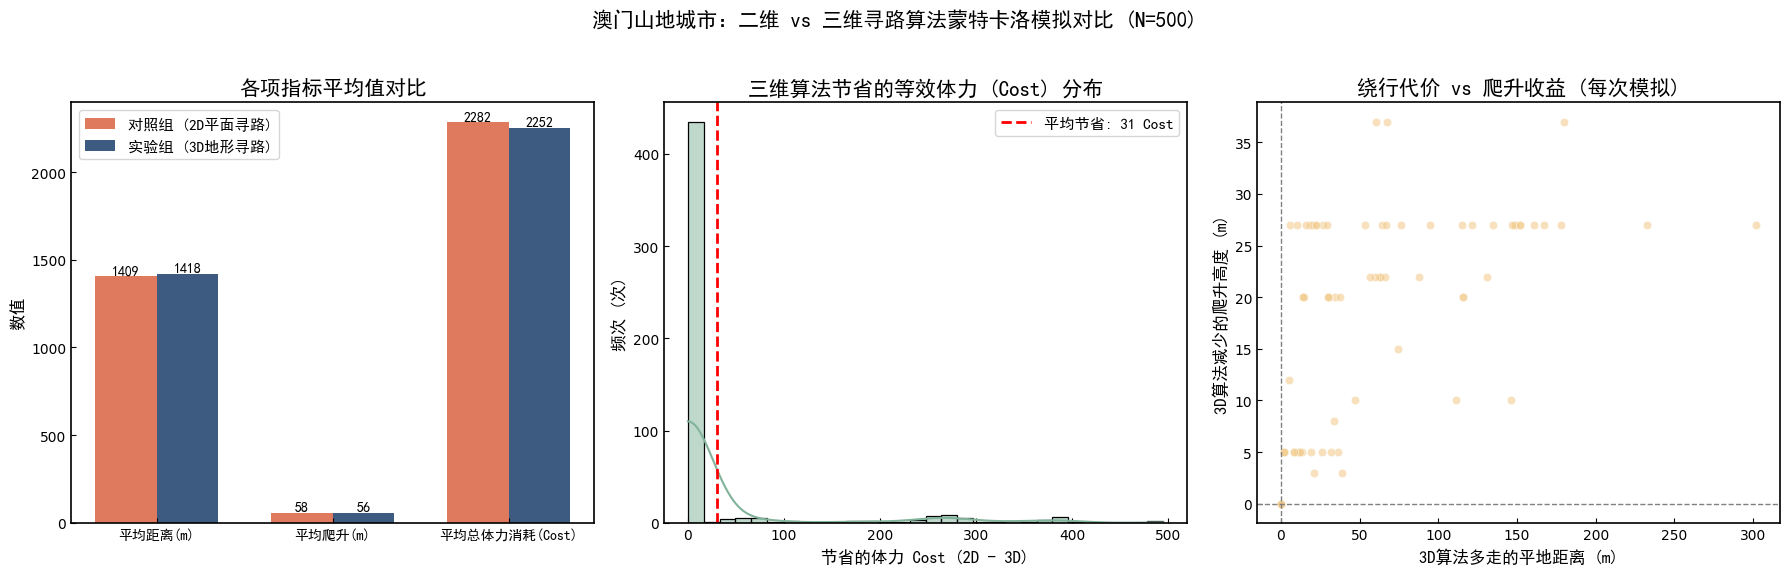

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. 字体下载与强制实体化 (完全绕过缓存)
# ==========================================
font_path = "SimHei.ttf"
if not os.path.exists(font_path):
    print("⏳ 正在 Colab 中下载中文字体...")
    try:
        urllib.request.urlretrieve("https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf", font_path)
        print("✅ 字体下载完成！")
    except Exception as e:
        print(f"⚠️ 字体下载失败: {e}")

# 【核心改动】不再使用全局 rcParams，而是直接创建不同字号的字体实体对象
if os.path.exists(font_path):
    zh_font_title = fm.FontProperties(fname=font_path, size=15, weight='bold')
    zh_font_label = fm.FontProperties(fname=font_path, size=12)
    zh_font_tick  = fm.FontProperties(fname=font_path, size=10)
    zh_font_legend = fm.FontProperties(fname=font_path, size=11)
else:
    # 极端降级情况
    zh_font_title = zh_font_label = zh_font_tick = zh_font_legend = fm.FontProperties()

mpl.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

import os
import urllib.request
import matplotlib.font_manager as fm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# ... [前面下载字体的代码保持不变] ...

# 1. 读取刚才导出的数据
df = pd.read_csv('macau_routing_monte_carlo_results.csv')

# 2. 创建一个 1x3 的图表矩阵
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# 【修改 1】全局标题使用 fontproperties
fig.suptitle('澳门山地城市：二维 vs 三维寻路算法蒙特卡洛模拟对比 (N=500)', fontproperties=zh_font_title)

# === 图表 1：核心指标均值对比 (柱状图) ===
metrics = ['平均距离(m)', '平均爬升(m)', '平均总体力消耗(Cost)']
mean_2d = [df['2D_Distance(m)'].mean(), df['2D_Climb(m)'].mean(), df['2D_Total_Cost'].mean()]
mean_3d = [df['3D_Distance(m)'].mean(), df['3D_Climb(m)'].mean(), df['3D_Total_Cost'].mean()]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, mean_2d, width, label='对照组 (2D平面寻路)', color='#E07A5F')
axes[0].bar(x + width/2, mean_3d, width, label='实验组 (3D地形寻路)', color='#3D5A80')

# 【修改 2】Y轴标签、标题、X轴刻度、图例 都加上字体参数
axes[0].set_ylabel('数值', fontproperties=zh_font_label)
axes[0].set_title('各项指标平均值对比', fontproperties=zh_font_title)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontproperties=zh_font_tick)
axes[0].legend(prop=zh_font_legend) # 注意：legend 用的是 prop 不是 fontproperties

# 为柱子添加数值标签
for i in range(len(metrics)):
    axes[0].text(i - width/2, mean_2d[i] + 10, f'{mean_2d[i]:.0f}', ha='center', fontproperties=zh_font_tick)
    axes[0].text(i + width/2, mean_3d[i] + 10, f'{mean_3d[i]:.0f}', ha='center', fontproperties=zh_font_tick)

# === 图表 2：体力消耗降低分布 (直方图/KDE) ===
df['Cost_Saved'] = df['2D_Total_Cost'] - df['3D_Total_Cost']

sns.histplot(df['Cost_Saved'], bins=30, kde=True, ax=axes[1], color='#81B29A')
axes[1].axvline(df['Cost_Saved'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'平均节省: {df["Cost_Saved"].mean():.0f} Cost')

# 【修改 3】第二张图的标题、标签、图例
axes[1].set_title('三维算法节省的等效体力 (Cost) 分布', fontproperties=zh_font_title)
axes[1].set_xlabel('节省的体力 Cost (2D - 3D)', fontproperties=zh_font_label)
axes[1].set_ylabel('频次 (次)', fontproperties=zh_font_label)
axes[1].legend(prop=zh_font_legend)

# === 图表 3：“绕远路与少爬坡”的博弈 (散点图) ===
df['Dist_Added'] = df['3D_Distance(m)'] - df['2D_Distance(m)']
df['Climb_Saved'] = df['2D_Climb(m)'] - df['3D_Climb(m)']

sns.scatterplot(x='Dist_Added', y='Climb_Saved', data=df, ax=axes[2], alpha=0.6, color='#F2CC8F')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].axvline(0, color='gray', linestyle='--', linewidth=1)

# 【修改 4】第三张图的标题和标签
axes[2].set_title('绕行代价 vs 爬升收益 (每次模拟)', fontproperties=zh_font_title)
axes[2].set_xlabel('3D算法多走的平地距离 (m)', fontproperties=zh_font_label)
axes[2].set_ylabel('3D算法减少的爬升高度 (m)', fontproperties=zh_font_label)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

✅ 字体与样式加载完成
📂 读取您提供的 3 个文件...
   • 景点完整数据.csv 加载成功，共 36 个景点
   • 步行路程表加载成功，尺寸 (36, 37)
   • 正式景点_商铺数据.xlsx 加载成功，共 20,492 行记录
✅ 唯一商户总数：443 个
   • 目标 3 大业态商户数量：
     餐饮美食类 → 288 个商户
     特色零售类 → 39 个商户
     休闲休憩类 → 73 个商户
   • 动态 v_max = 25000
🚀 开始蒙特卡罗模拟（每位旅客推荐 3 个商铺，共 3000 推荐）...
   β = 0.00 | 模型3 小商户: 69 | 大商户: 2931  (总 3000)
   β = 0.05 | 模型3 小商户: 138 | 大商户: 2862  (总 3000)
   β = 0.10 | 模型3 小商户: 243 | 大商户: 2757  (总 3000)
   β = 0.15 | 模型3 小商户: 381 | 大商户: 2619  (总 3000)
   β = 0.20 | 模型3 小商户: 715 | 大商户: 2285  (总 3000)
   β = 0.25 | 模型3 小商户: 1009 | 大商户: 1991  (总 3000)
   β = 0.30 | 模型3 小商户: 1317 | 大商户: 1683  (总 3000)
   β = 0.35 | 模型3 小商户: 1679 | 大商户: 1321  (总 3000)
   β = 0.40 | 模型3 小商户: 2081 | 大商户: 919  (总 3000)
   β = 0.45 | 模型3 小商户: 2307 | 大商户: 693  (总 3000)
   β = 0.50 | 模型3 小商户: 2493 | 大商户: 507  (总 3000)
   β = 0.55 | 模型3 小商户: 2625 | 大商户: 375  (总 3000)
   β = 0.60 | 模型3 小商户: 2812 | 大商户: 188  (总 3000)
   β = 0.65 | 模型3 小商户: 2846 | 大商户: 154  (总 3000)
   β = 0.70 | 模型3 小商户: 2872 | 大商

   β = 1.00 | 模型3 小商户: 2939 | 大商户: 61  (总 3000)


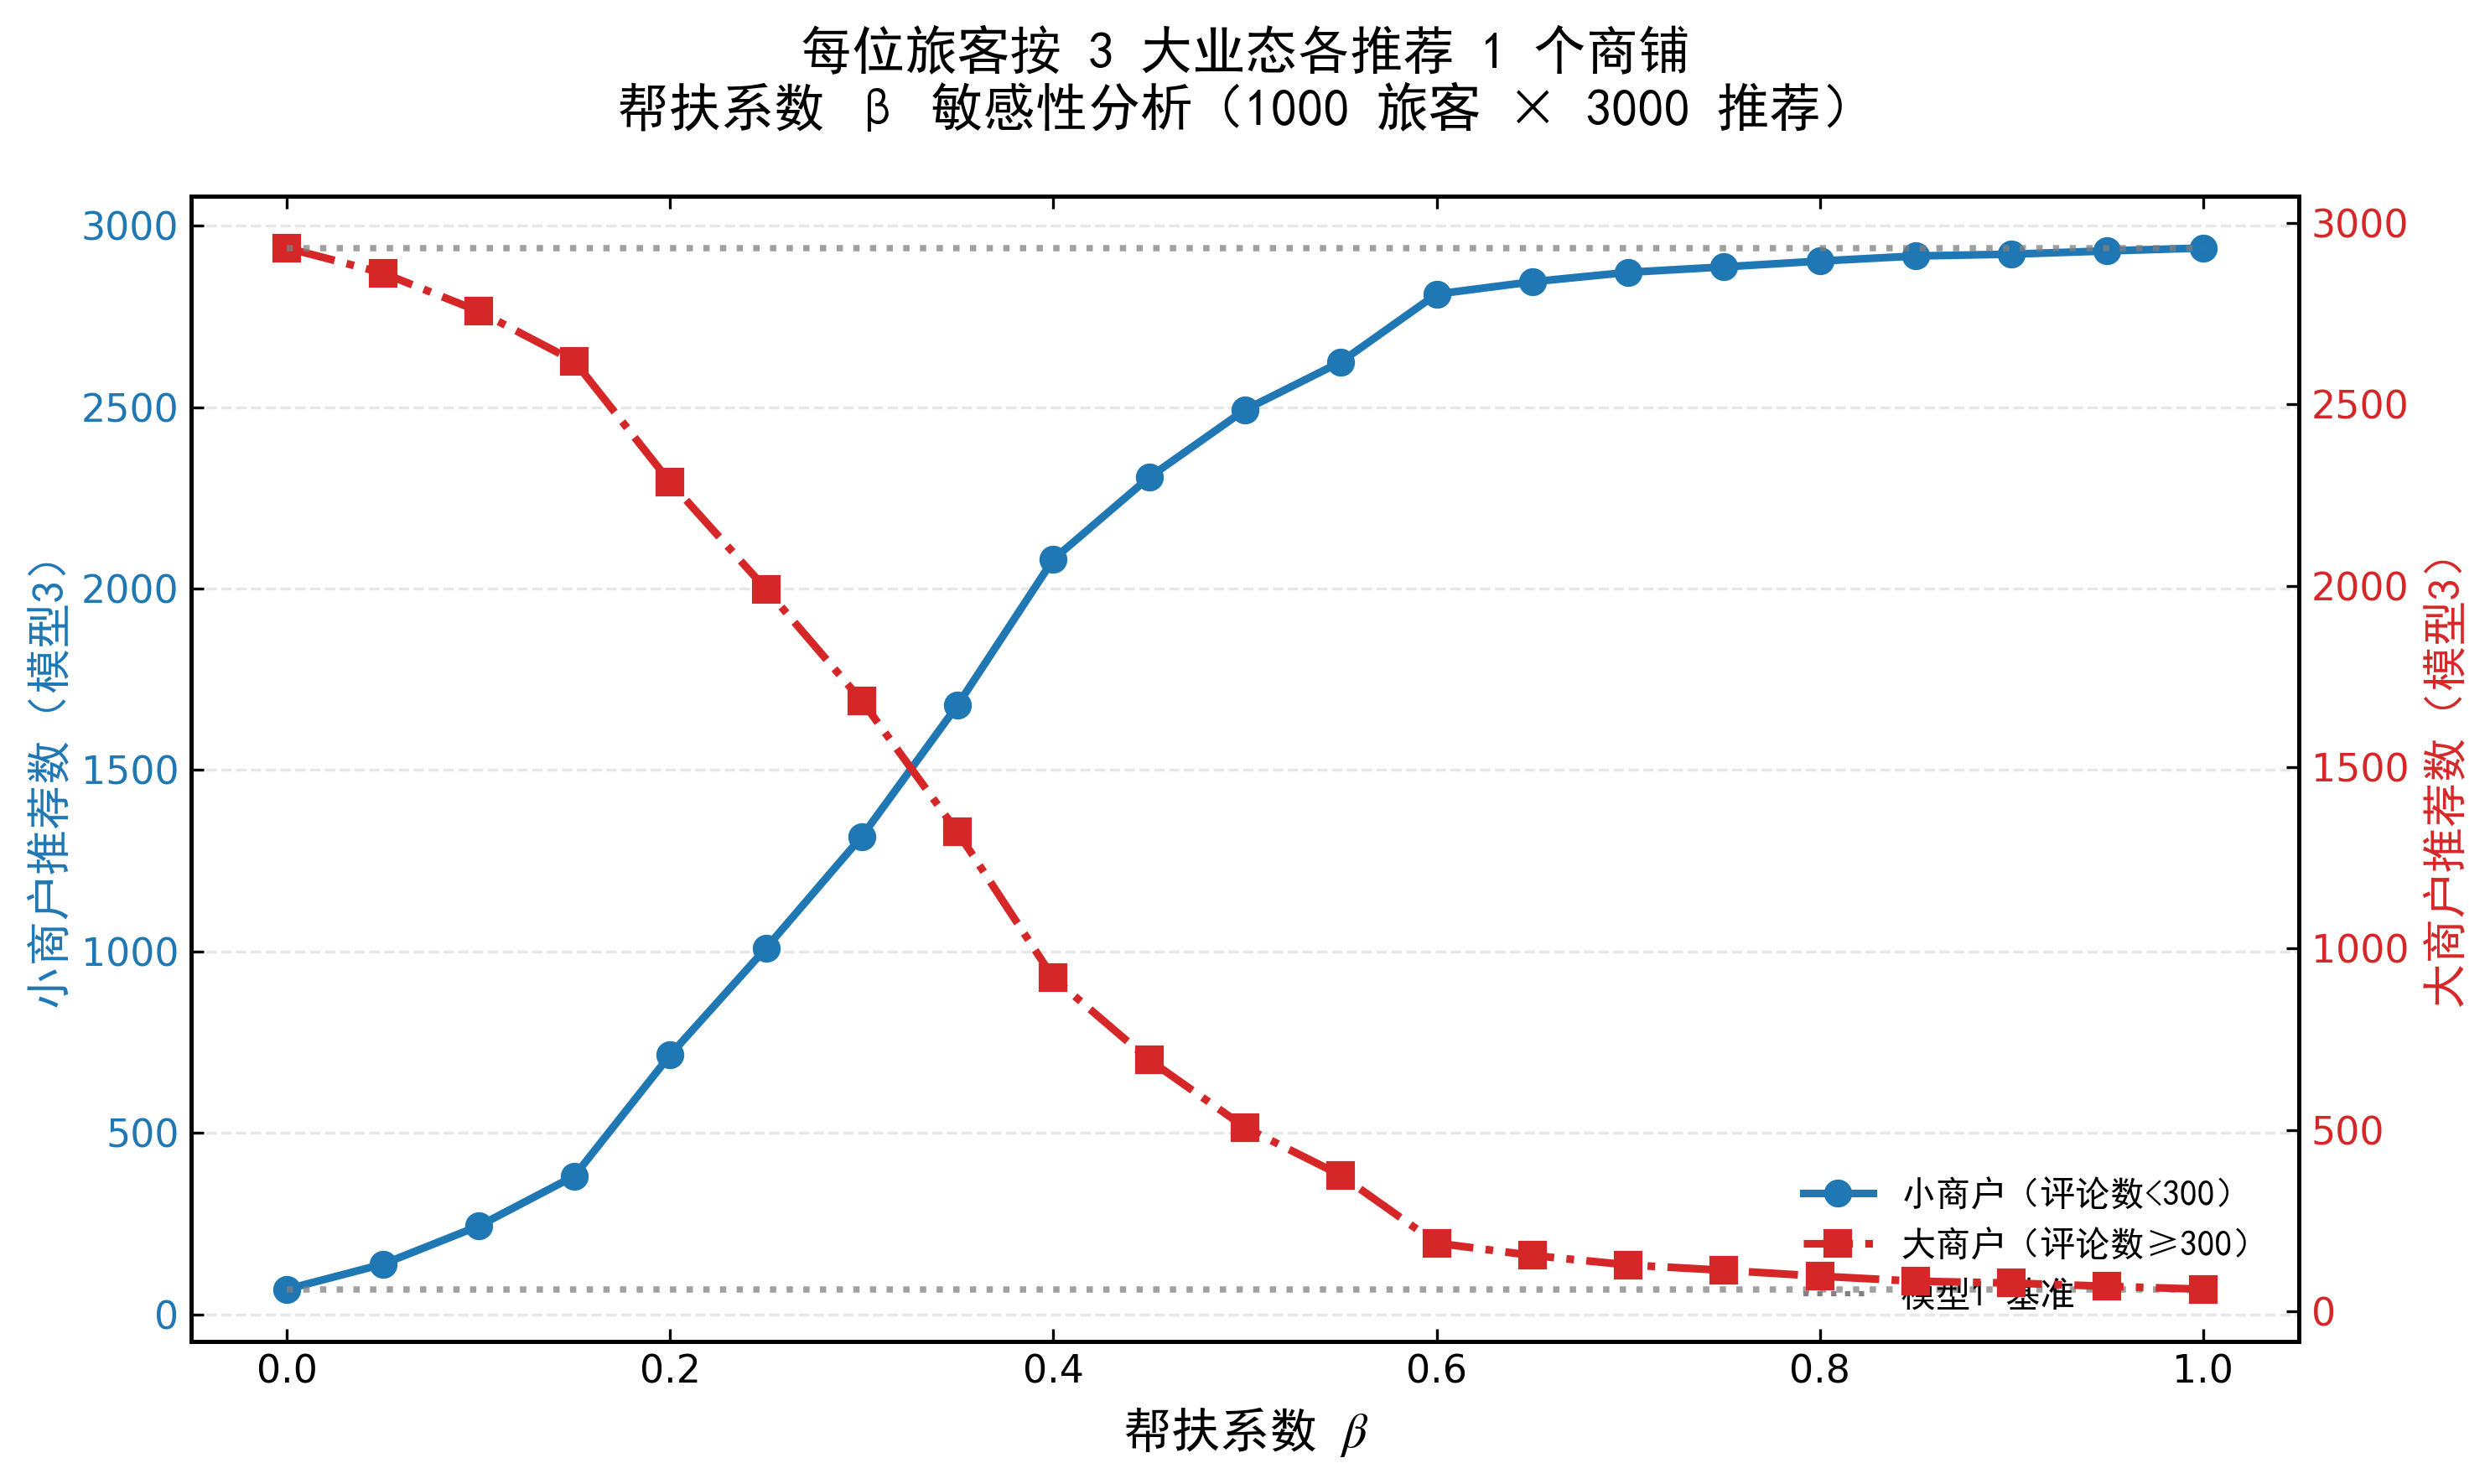

,β,模型3_小商户推荐数,模型3_大商户推荐数,模型3_小商户占比(%),模型1_小商户推荐数,模型1_大商户推荐数,模型1_小商户占比(%)
0,0.00,69,2931,2.30,69,2931,2.30
1,0.05,138,2862,4.60,69,2931,2.30
2,0.10,243,2757,8.10,69,2931,2.30
3,0.15,381,2619,12.70,69,2931,2.30
4,0.20,715,2285,23.83,69,2931,2.30
5,0.25,1009,1991,33.63,69,2931,2.30
6,0.30,1317,1683,43.90,69,2931,2.30
7,0.35,1679,1321,55.97,69,2931,2.30
8,0.40,2081,919,69.37,69,2931,2.30
9,0.45,2307,693,76.90,69,2931,2.30



🎉 全部完成！
   • 每位旅客已获得餐饮美食类、特色零售类、休闲休憩类各 1 个商铺推荐
   • 双 Y 轴图已生成（模型3 随 β 变化 + 模型1 基准）
   • 您可以直接修改 TARGET_CATEGORIES 或 SMALL_THRESHOLD 后重新运行


In [18]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
from collections import defaultdict
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# === 0. 全局学术排版设置（中英完美兼容）
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

font_filename = 'SimHei.ttf'
if not os.path.exists(font_filename):
    os.system(f'wget -q -O {font_filename} https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf')
try:
    zh_font = fm.FontProperties(fname=font_filename, size=12)
    zh_font_legend = fm.FontProperties(fname=font_filename, size=10)
    zh_font_anno = fm.FontProperties(fname=font_filename, size=10)
except:
    zh_font = fm.FontProperties(family='sans-serif', size=12)
    zh_font_legend = fm.FontProperties(family='sans-serif', size=10)
    zh_font_anno = fm.FontProperties(family='sans-serif', size=10)

print("✅ 字体与样式加载完成")

# ==========================================
# === 1. 读取 3 个文件
# ==========================================
print("📂 读取您提供的 3 个文件...")
attr_df = pd.read_csv('景点完整数据.csv')
print(f"   • 景点完整数据.csv 加载成功，共 {len(attr_df)} 个景点")

walking_df = pd.read_excel('澳門景點步行路程表_完整版 V11 - 1.xlsx', sheet_name='表1')
print(f"   • 步行路程表加载成功，尺寸 {walking_df.shape}")

merchants_raw = pd.read_excel('正式景点_商铺数据.xlsx', sheet_name='表1')
print(f"   • 正式景点_商铺数据.xlsx 加载成功，共 {len(merchants_raw):,} 行记录")

# ==========================================
# === 2. 构建商户数据库（按业态分组）
# ==========================================
merchants_info = {}
category_to_merchants = defaultdict(dict)   # 按业态分组

for _, row in merchants_raw.iterrows():
    m_name = row['商户名称']
    cat = row['业态']

    if m_name not in merchants_info:   # 去重，取首次出现的特征
        merchants_info[m_name] = {
            'features': np.array([row['网红打卡']/5.0, row['本土程度']/5.0, row['环境氛围']/5.0]),
            'rating': float(row['网络评分']),
            'reviews': int(row['网络评论数']),
            'category': cat
        }

    # 同时按业态分组（允许同一商户在不同景点出现，但仍归属同一业态）
    if m_name not in category_to_merchants[cat]:
        category_to_merchants[cat][m_name] = merchants_info[m_name]

print(f"✅ 唯一商户总数：{len(merchants_info)} 个")
print(f"   • 目标 3 大业态商户数量：")
for cat in ['餐饮美食类', '特色零售类', '休闲休憩类']:
    cnt = len(category_to_merchants[cat])
    print(f"     {cat} → {cnt} 个商户")

v_max = max(m['reviews'] for m in merchants_info.values()) if merchants_info else 3500
print(f"   • 动态 v_max = {v_max}")

# 指定用户要求的 3 大业态（严格按您的描述）
TARGET_CATEGORIES = ['餐饮美食类', '特色零售类', '休闲休憩类']
SMALL_THRESHOLD = 300

# ==========================================
# === 3. 核心评分函数（模型1 + 模型3）
# ==========================================
def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    return 0.0 if dot == 0 else dot / (np.linalg.norm(v1) * np.linalg.norm(v2))

def get_best_merchant_in_category(user_pref, cat_merchants, beta, model_type="model3", v_max=3500):
    """在指定业态内选出最优商户"""
    best_m, max_score = None, -1.0
    for m_id, m_data in cat_merchants.items():
        if m_data['rating'] < 3.8:
            continue
        M_ij = cosine_similarity(user_pref, m_data['features'])
        r = m_data['reviews']
        w = r / (r + 30) if r > 0 else 0
        Q_j = w * m_data['rating'] + (1 - w) * 3.5
        V_j = 1 - (math.log10(r + 1) / math.log10(v_max + 1)) if r >= 0 else 0

        if model_type == "model1":
            score = M_ij * (Q_j / 5.0)
        else:  # model3
            score = M_ij * ((Q_j / 5.0) + beta * V_j)

        if score > max_score:
            max_score = score
            best_m = m_id
    return best_m

# ==========================================
# === 4. 蒙特卡罗模拟（1000 旅客 × 3 业态 × 21 个 β）
# ==========================================
np.random.seed(42)
num_tourists = 1000
virtual_tourists = np.random.rand(num_tourists, 3)   # [网红打卡, 本土程度, 环境氛围]

betas = np.arange(0.0, 1.05, 0.05)

small_model3 = []
large_model3 = []
small_model1 = []
large_model1 = []

print("🚀 开始蒙特卡罗模拟（每位旅客推荐 3 个商铺，共 3000 推荐）...")

for beta in betas:
    small3, large3 = 0, 0
    small1, large1 = 0, 0

    for i in range(num_tourists):
        user_pref = virtual_tourists[i]

        # === 模型3（含帮扶 β）===
        for cat in TARGET_CATEGORIES:
            best_m = get_best_merchant_in_category(user_pref, category_to_merchants[cat], beta, "model3", v_max)
            if best_m:
                rev = merchants_info[best_m]['reviews']
                if rev < SMALL_THRESHOLD:
                    small3 += 1
                else:
                    large3 += 1

        # === 模型1（纯 Q_j，无帮扶）===
        for cat in TARGET_CATEGORIES:
            best_m = get_best_merchant_in_category(user_pref, category_to_merchants[cat], 0.0, "model1", v_max)
            if best_m:
                rev = merchants_info[best_m]['reviews']
                if rev < SMALL_THRESHOLD:
                    small1 += 1
                else:
                    large1 += 1

    small_model3.append(small3)
    large_model3.append(large3)
    small_model1.append(small1)
    large_model1.append(large1)

    print(f"   β = {beta:.2f} | 模型3 小商户: {small3} | 大商户: {large3}  (总 3000)")

# ==========================================
# === 5. 学术级双 Y 轴敏感性分析图
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

color_small = '#1f77b4'
color_large = '#d62728'

ax1.set_xlabel('帮扶系数 $\\beta$', fontproperties=zh_font, fontsize=14)
ax1.set_ylabel('小商户推荐数（模型3）', fontproperties=zh_font, fontsize=13, color=color_small)
line_s3 = ax1.plot(betas, small_model3, color=color_small, linestyle='-', marker='o',
                   linewidth=2.2, markersize=7, label='小商户（评论数<300）')
ax1.tick_params(axis='y', labelcolor=color_small)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('大商户推荐数（模型3）', fontproperties=zh_font, fontsize=13, color=color_large)
line_l3 = ax2.plot(betas, large_model3, color=color_large, linestyle='-.', marker='s',
                   linewidth=2.2, markersize=7, label='大商户（评论数≥300）')
ax2.tick_params(axis='y', labelcolor=color_large)

# 模型1 基准线（灰色虚线）
ax1.plot(betas, small_model1, color='gray', linestyle=':', linewidth=1.8, alpha=0.75, label='模型1 小商户（基准）')
ax2.plot(betas, large_model1, color='gray', linestyle=':', linewidth=1.8, alpha=0.75, label='模型1 大商户（基准）')

ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax1.tick_params(axis='x', top=True)
ax2.tick_params(axis='y', direction='in')

lines = line_s3 + line_l3
labels = [l.get_label() for l in lines]
ax1.legend(lines + [plt.Line2D([0],[0], color='gray', linestyle=':')],
           labels + ['模型1 基准'], loc='lower right', frameon=False, prop=zh_font_legend)

plt.title('每位旅客按 3 大业态各推荐 1 个商铺\n帮扶系数 β 敏感性分析（1000 旅客 × 3000 推荐）',
          fontproperties=zh_font, fontsize=15, pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# === 6. 输出完整结果表格
# ==========================================
result_df = pd.DataFrame({
    'β': betas,
    '模型3_小商户推荐数': small_model3,
    '模型3_大商户推荐数': large_model3,
    '模型3_小商户占比(%)': [round(100 * s / 3000, 2) for s in small_model3],
    '模型1_小商户推荐数': small_model1,
    '模型1_大商户推荐数': large_model1,
    '模型1_小商户占比(%)': [round(100 * s / 3000, 2) for s in small_model1]
})
display(result_df.style.set_caption("📊 完整敏感性分析结果表（每 β 共 3000 推荐）").format(precision=2))

print("\n🎉 全部完成！")
print("   • 每位旅客已获得餐饮美食类、特色零售类、休闲休憩类各 1 个商铺推荐")
print("   • 双 Y 轴图已生成（模型3 随 β 变化 + 模型1 基准）")
print("   • 您可以直接修改 TARGET_CATEGORIES 或 SMALL_THRESHOLD 后重新运行")